<a href="https://colab.research.google.com/github/nurmd2002/bn4601a-dr/blob/main/Diabetic_Retinopathy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Referable diabetic retinopathy screening, end to end

BN4601A individual assignment. Same structure as the lecture's YOLO11 notebook,
rebuilt for image classification.

**Task:** grade fundus images 0-4 (ICDR), then collapse to the screening decision
that actually matters: is this patient **referable** (grade >= 2)?

**Data:** `bumbledeep/aptos` — APTOS 2019, Aravind Eye Hospital, India. 3,662 images.

Runtime -> Change runtime type -> **T4 GPU** -> Save.

## Step 1: Start a GPU Colab

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## Step 2: Install the packages

In [2]:
!pip -q install -U datasets timm huggingface_hub gradio scikit-learn

import timm, datasets, sklearn
print("timm:", timm.__version__)
print("datasets:", datasets.__version__)
print("sklearn:", sklearn.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.1 MB/s eta 0:00:00
timm: 1.0.29
datasets: 5.0.1
sklearn: 1.9.0


## Step 3: Meet our dataset

`bumbledeep/aptos` is a Hugging Face mirror of the APTOS 2019 Blindness Detection
dataset. Columns: `image`, `label_code` (0-4), `label` (string).

In [3]:
from datasets import load_dataset

ds = load_dataset("bumbledeep/aptos", split="train")

print(ds)
print()
print(ds.features)

README.md:   0%|          | 0.00/5.36k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  250MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3662 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label_code', 'label'],
    num_rows: 3662
})

{'image': Image(mode=None, decode=True), 'label_code': Value('int64'), 'label': Value('string')}


## Step 4: Count everything

In [4]:
import collections
import pandas as pd

GRADE_NAMES = {
    0: "No DR",
    1: "Mild NPDR",
    2: "Moderate NPDR",
    3: "Severe NPDR",
    4: "Proliferative DR",
}

labels = ds["label_code"]
counts = collections.Counter(labels)
N = len(labels)

pd.DataFrame({
    "grade": sorted(counts),
    "name": [GRADE_NAMES[g] for g in sorted(counts)],
    "n": [counts[g] for g in sorted(counts)],
    "percent": [round(100*counts[g]/N, 1) for g in sorted(counts)],
})

,grade,name,n,percent
0,0,No DR,1805,49.3
1,1,Mild NPDR,370,10.1
2,2,Moderate NPDR,999,27.3
3,3,Severe NPDR,193,5.3
4,4,Proliferative DR,295,8.1


### The number every metric must be compared against

A model that ignores the image and always answers "No DR" scores the majority
fraction. If your accuracy is near that, your model has learned nothing.

In [5]:
majority = max(counts.values()) / N
referable_rate = sum(v for k, v in counts.items() if k >= 2) / N

print(f"images                           : {N}")
print(f"always-predict-'No DR' accuracy   : {majority:.1%}")
print(f"referable prevalence (grade >= 2) : {referable_rate:.1%}")

images                           : 3662
always-predict-'No DR' accuracy   : 49.3%
referable prevalence (grade >= 2) : 40.6%


## Step 5: Never trust labels you haven't seen

One image per grade. Look before you train.

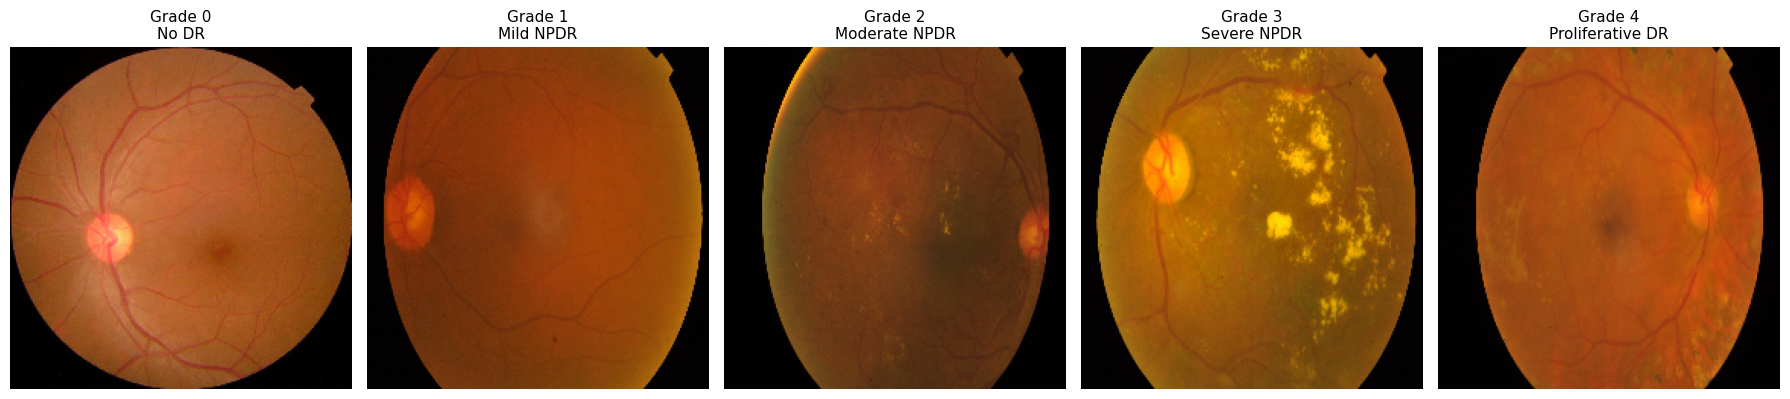

In [6]:
import matplotlib.pyplot as plt

first_idx = {}
for i, g in enumerate(labels):
    first_idx.setdefault(g, i)
    if len(first_idx) == 5:
        break

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for g, ax in zip(sorted(first_idx), axes):
    ax.imshow(ds[first_idx[g]]["image"])
    ax.set_title(f"Grade {g}\n{GRADE_NAMES[g]}", fontsize=11)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [7]:
sizes = [ds[i]["image"].size for i in range(0, N, max(1, N//200))]
sz = pd.DataFrame(sizes, columns=["width", "height"])
print(sz.groupby(["width","height"]).size().sort_values(ascending=False).head())

width  height
224    224       204
dtype: int64


## Step 6: Create train / val / test splits

Stratified so every split has the same class balance. `seed=42` throughout.

- **Train** learns the weights
- **Validation** picks the best epoch and the decision threshold
- **Test** is touched exactly once, at the end

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
idx = np.arange(N)
y = np.array(labels)

train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, stratify=y, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y[temp_idx], random_state=SEED
)

ds_train = ds.select(train_idx)
ds_val   = ds.select(val_idx)
ds_test  = ds.select(test_idx)

for name, split_idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    dist = collections.Counter(y[split_idx])
    print(f"{name:5s}: {len(split_idx):5d} images | " +
          " ".join(f"g{g}={dist[g]}" for g in sorted(dist)))

train:  2563 images | g0=1263 g1=259 g2=699 g3=135 g4=207
val  :   549 images | g0=271 g1=55 g2=150 g3=29 g4=44
test :   550 images | g0=271 g1=56 g2=150 g3=29 g4=44


## Step 7: Preprocessing and augmentation

Augmentation only on train. Validation and test see the clean image, otherwise your
numbers measure a moving target.

Fundus images have no meaningful left/right or up/down orientation, so flips and
rotations are safe here. Colour jitter is deliberately mild: DR severity is partly
carried by subtle colour differences and aggressive jitter destroys signal.

In [9]:
from torchvision import transforms

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [10]:
from torch.utils.data import Dataset, DataLoader

class FundusDataset(Dataset):
    def __init__(self, hf_split, tf):
        self.ds = hf_split
        self.tf = tf

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        row = self.ds[i]
        img = row["image"].convert("RGB")
        return self.tf(img), row["label_code"]

BATCH_SIZE = 32

train_loader = DataLoader(FundusDataset(ds_train, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(FundusDataset(ds_val, eval_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(FundusDataset(ds_test, eval_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, yb.shape)

batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


## Step 8: Start from a pretrained model

Not training from scratch. ResNet-18 already knows edges, textures and blobs from
ImageNet; we replace its final layer with a 5-class head and retrain on retinas.

ResNet-18 matches the base model used in the lecture's AutoTrain example.

In [11]:
import timm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model("resnet18", pretrained=True, num_classes=5).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")
print("device:", DEVICE)

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

parameters: 11,179,077
device: cuda


### Class weighting

Three quarters of the data is grade 0. Without weighting, predicting "No DR" for
everything is a local minimum the model is happy to sit in. Weights are inversely
proportional to class frequency.

In [12]:
import torch.nn as nn

train_counts = collections.Counter(y[train_idx])
weights = torch.tensor(
    [len(train_idx) / (5 * train_counts[g]) for g in range(5)],
    dtype=torch.float32
).to(DEVICE)

print("class weights:", weights.cpu().numpy().round(2))

criterion = nn.CrossEntropyLoss(weight=weights)

class weights: [0.41 1.98 0.73 3.8  2.48]


## Step 9: Fine-tune

Quadratic weighted kappa is the standard DR metric: it penalises being wrong by
three grades far more than being wrong by one. We checkpoint on validation kappa,
not on the final epoch.

In [13]:
from sklearn.metrics import cohen_kappa_score

EPOCHS = 20
LR = 3e-4

torch.manual_seed(SEED)
np.random.seed(SEED)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

@torch.no_grad()
def predict_split(m, loader):
    m.eval()
    probs, trues = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            out = m(xb)
        probs.append(torch.softmax(out.float(), 1).cpu())
        trues.append(yb)
    return torch.cat(probs).numpy(), torch.cat(trues).numpy()

history = []
best_kappa = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            loss = criterion(model(xb), yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running += loss.item() * xb.size(0)

    scheduler.step()
    train_loss = running / len(train_idx)

    vp, vt = predict_split(model, val_loader)
    val_pred = vp.argmax(1)
    kappa = cohen_kappa_score(vt, val_pred, weights="quadratic")
    acc = (val_pred == vt).mean()

    history.append({"epoch": epoch, "train_loss": train_loss,
                    "val_kappa": kappa, "val_acc": acc})

    flag = ""
    if kappa > best_kappa:
        best_kappa = kappa
        torch.save(model.state_dict(), "best.pt")
        flag = "  <- saved"

    print(f"epoch {epoch:2d}/{EPOCHS}  loss {train_loss:.4f}  "
          f"val kappa {kappa:.4f}  val acc {acc:.3f}{flag}")

print(f"\nbest validation kappa: {best_kappa:.4f}")

epoch  1/20  loss 1.3699  val kappa 0.7138  val acc 0.643  <- saved
epoch  2/20  loss 1.0562  val kappa 0.7770  val acc 0.719  <- saved
epoch  3/20  loss 0.9170  val kappa 0.7734  val acc 0.719
epoch  4/20  loss 0.8408  val kappa 0.7196  val acc 0.679
epoch  5/20  loss 0.8085  val kappa 0.8452  val acc 0.769  <- saved
epoch  6/20  loss 0.7451  val kappa 0.8267  val acc 0.765
epoch  7/20  loss 0.6971  val kappa 0.8147  val acc 0.761
epoch  8/20  loss 0.6454  val kappa 0.8541  val acc 0.783  <- saved
epoch  9/20  loss 0.6343  val kappa 0.8404  val acc 0.785
epoch 10/20  loss 0.5982  val kappa 0.8544  val acc 0.780  <- saved
epoch 11/20  loss 0.5634  val kappa 0.8576  val acc 0.798  <- saved
epoch 12/20  loss 0.5318  val kappa 0.8653  val acc 0.796  <- saved
epoch 13/20  loss 0.4921  val kappa 0.8430  val acc 0.780
epoch 14/20  loss 0.4747  val kappa 0.8647  val acc 0.811
epoch 15/20  loss 0.4615  val kappa 0.8541  val acc 0.772
epoch 16/20  loss 0.4521  val kappa 0.8207  val acc 0.760
ep

## Step 10: What happened during training

If validation kappa plateaus early, you can cut epochs. If it was still climbing at
the end, run longer. This figure goes in your report.

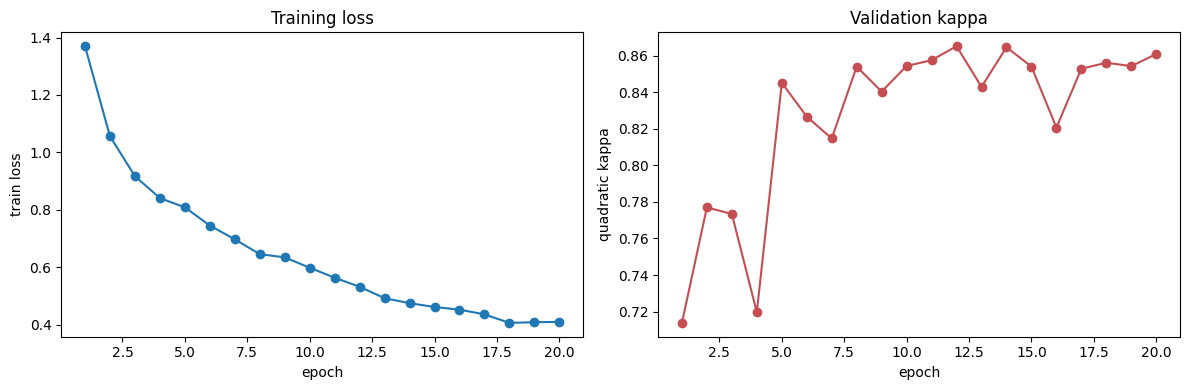

In [14]:
h = pd.DataFrame(history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h.epoch, h.train_loss, marker="o")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss"); ax[0].set_title("Training loss")
ax[1].plot(h.epoch, h.val_kappa, marker="o", color="#c44e52")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("quadratic kappa"); ax[1].set_title("Validation kappa")
plt.tight_layout(); plt.show()

## Step 11: Load the best checkpoint

In [15]:
best_model = timm.create_model("resnet18", pretrained=False, num_classes=5).to(DEVICE)
best_model.load_state_dict(torch.load("best.pt", map_location=DEVICE))
best_model.eval()
print("loaded best.pt")

loaded best.pt


## Step 12: Evaluate on the held-out test set

First touch of the test split. Two views:

- **Five-class** grading — kappa and the confusion matrix
- **Binary referable** — the decision a screening programme actually makes

In [16]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, cohen_kappa_score)

test_probs, test_true = predict_split(best_model, test_loader)
test_pred = test_probs.argmax(1)

print("accuracy       :", round((test_pred == test_true).mean(), 4))
print("majority basel.:", round(majority, 4))
print("kappa (quad)   :", round(cohen_kappa_score(test_true, test_pred, weights="quadratic"), 4))
print()
print(classification_report(test_true, test_pred,
                           target_names=[GRADE_NAMES[g] for g in range(5)],
                           digits=3, zero_division=0))

accuracy       : 0.7782
majority basel.: 0.4929
kappa (quad)   : 0.8605

                  precision    recall  f1-score   support

           No DR      0.960     0.970     0.965       271
       Mild NPDR      0.515     0.607     0.557        56
   Moderate NPDR      0.764     0.627     0.689       150
     Severe NPDR      0.333     0.483     0.394        29
Proliferative DR      0.511     0.523     0.517        44

        accuracy                          0.778       550
       macro avg      0.617     0.642     0.624       550
    weighted avg      0.792     0.778     0.782       550



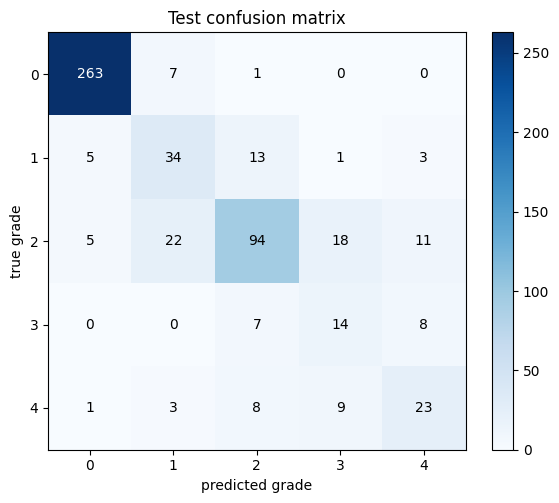

In [17]:
cm = confusion_matrix(test_true, test_pred, labels=range(5))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(range(5)); ax.set_yticklabels(range(5))
ax.set_xlabel("predicted grade"); ax.set_ylabel("true grade")
ax.set_title("Test confusion matrix")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

### The screening decision

Collapse to referable vs not. `P(referable)` is the summed probability of grades 2-4.

Sensitivity is what matters most: a missed referable patient can lose vision, while a
false positive costs one unnecessary appointment.

In [18]:
p_referable = test_probs[:, 2:].sum(1)
y_referable = (test_true >= 2).astype(int)

auc = roc_auc_score(y_referable, p_referable)
print("referable AUC:", round(auc, 4))

def sens_spec(y_true, scores, thr):
    pred = (scores >= thr).astype(int)
    tp = ((pred == 1) & (y_true == 1)).sum()
    tn = ((pred == 0) & (y_true == 0)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    return tp/(tp+fn) if tp+fn else 0.0, tn/(tn+fp) if tn+fp else 0.0

rows = []
for thr in np.arange(0.05, 0.96, 0.05):
    se, sp = sens_spec(y_referable, p_referable, thr)
    rows.append({"threshold": round(thr,2), "sensitivity": round(se,3),
                 "specificity": round(sp,3)})
pd.DataFrame(rows)

referable AUC: 0.9802


,threshold,sensitivity,specificity
0,0.05,1.000,0.780
1,0.10,0.996,0.835
2,0.15,0.982,0.850
3,0.20,0.955,0.878
4,0.25,0.946,0.896
5,0.30,0.942,0.905
6,0.35,0.933,0.905
7,0.40,0.919,0.920
8,0.45,0.901,0.927
9,0.50,0.879,0.939


### Choose an operating point

Pick the lowest threshold that meets a target sensitivity, then report the
specificity you get there. State the target and the reasoning in your report.

In [19]:
TARGET_SENS = 0.85

chosen = None
for thr in np.arange(0.95, 0.04, -0.01):
    se, sp = sens_spec(y_referable, p_referable, thr)
    if se >= TARGET_SENS:
        chosen = (thr, se, sp)
        break

if chosen:
    thr, se, sp = chosen
    print(f"threshold {thr:.2f}  ->  sensitivity {se:.3f}, specificity {sp:.3f}")
else:
    print(f"No threshold reaches {TARGET_SENS:.0%} sensitivity on this test set.")

threshold 0.59  ->  sensitivity 0.852, specificity 0.948


## Step 13: Test on an unseen image

Quantitative evaluation and qualitative inspection should both be performed.

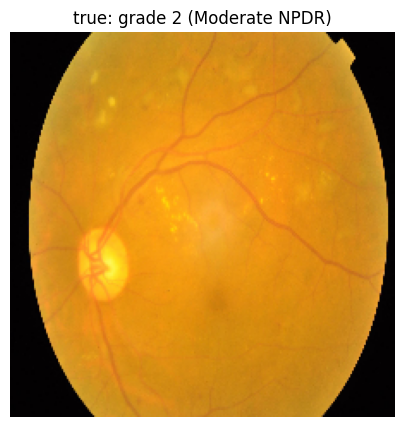

  grade 0 No DR                0.002
  grade 1 Mild NPDR            0.011
  grade 2 Moderate NPDR        0.152
  grade 3 Severe NPDR          0.720
  grade 4 Proliferative DR     0.115

P(referable) = 0.987


In [20]:
i = 0
img = ds_test[i]["image"].convert("RGB")
true_g = ds_test[i]["label_code"]

with torch.no_grad():
    p = torch.softmax(best_model(eval_tf(img).unsqueeze(0).to(DEVICE)).float(), 1)[0].cpu().numpy()

plt.figure(figsize=(5,5)); plt.imshow(img); plt.axis("off")
plt.title(f"true: grade {true_g} ({GRADE_NAMES[true_g]})")
plt.show()

for g in range(5):
    print(f"  grade {g} {GRADE_NAMES[g]:20s} {p[g]:.3f}")
print(f"\nP(referable) = {p[2:].sum():.3f}")

## Step 14: Turn the model into an app

In [21]:
import gradio as gr

def screen(image):
    if image is None:
        return {}, "Upload a fundus image."
    x = eval_tf(image.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = torch.softmax(best_model(x).float(), 1)[0].cpu().numpy()

    scores = {GRADE_NAMES[g]: float(p[g]) for g in range(5)}
    pr = float(p[2:].sum())
    verdict = f"P(referable) = {pr:.2f} -> " + ("REFER" if pr >= 0.5 else "NO REFER")
    return scores, verdict

demo = gr.Interface(
    fn=screen,
    inputs=gr.Image(type="pil", label="Upload Fundus Image"),
    outputs=[gr.Label(label="DR grade probabilities"),
             gr.Textbox(label="Screening decision")],
    title="Diabetic Retinopathy Screening Demo",
    description=(
        "Educational demonstration only. "
        "Not for diagnosis or clinical decision-making."
    ),
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fcc8fa90bea0631c3e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 15: Save the model



In [24]:
from huggingface_hub import login
login()

In [25]:
from huggingface_hub import HfApi, create_repo
REPO = "Moodski/aptos-dr-resnet18"
create_repo(REPO, exist_ok=True)
HfApi().upload_file(path_or_fileobj="best.pt", path_in_repo="best.pt", repo_id=REPO)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/best.pt            :   1%|1         |  560kB / 44.8MB            

CommitInfo(commit_url='https://huggingface.co/Moodski/aptos-dr-resnet18/commit/2727f99ef550375c72961a64d12ad288fd8c408c', commit_message='Upload best.pt with huggingface_hub', commit_description='', oid='2727f99ef550375c72961a64d12ad288fd8c408c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Moodski/aptos-dr-resnet18', endpoint='https://huggingface.co', repo_type='model', repo_id='Moodski/aptos-dr-resnet18'), pr_revision=None, pr_num=None)

In [26]:
import json
json.dump({
    "dataset": "bumbledeep/aptos",
    "backbone": "resnet18", "img_size": 224, "epochs": 20, "seed": 42,
    "test_kappa_quadratic": 0.8605,
    "test_accuracy": 0.7782,
    "majority_baseline": 0.4929,
    "macro_f1": 0.624,
    "val_kappa_best": 0.8653,
}, open("metrics.json", "w"), indent=2)

HfApi().upload_file(path_or_fileobj="metrics.json",
                    path_in_repo="metrics.json", repo_id=REPO)

CommitInfo(commit_url='https://huggingface.co/Moodski/aptos-dr-resnet18/commit/936addd331050f14bf286ff0b3b7a61d3596f0ae', commit_message='Upload metrics.json with huggingface_hub', commit_description='', oid='936addd331050f14bf286ff0b3b7a61d3596f0ae', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Moodski/aptos-dr-resnet18', endpoint='https://huggingface.co', repo_type='model', repo_id='Moodski/aptos-dr-resnet18'), pr_revision=None, pr_num=None)

In [27]:
from huggingface_hub import list_repo_files
f = list_repo_files("ctmedtech/DDR-dataset", repo_type="dataset")
print(len(f)); print(f[:40])

19738
['.gitattributes', 'DR_grading/test.txt', 'DR_grading/test/007-2809-100.jpg', 'DR_grading/test/007-2811-100.jpg', 'DR_grading/test/007-2812-100.jpg', 'DR_grading/test/007-2814-100.jpg', 'DR_grading/test/007-2815-100.jpg', 'DR_grading/test/007-2823-100.jpg', 'DR_grading/test/007-2824-100.jpg', 'DR_grading/test/007-2830-100.jpg', 'DR_grading/test/007-2831-100.jpg', 'DR_grading/test/007-2834-100.jpg', 'DR_grading/test/007-2835-100.jpg', 'DR_grading/test/007-2836-100.jpg', 'DR_grading/test/007-2837-100.jpg', 'DR_grading/test/007-2839-100.jpg', 'DR_grading/test/007-2840-100.jpg', 'DR_grading/test/007-2841-100.jpg', 'DR_grading/test/007-2842-100.jpg', 'DR_grading/test/007-2843-100.jpg', 'DR_grading/test/007-2844-100.jpg', 'DR_grading/test/007-2845-100.jpg', 'DR_grading/test/007-2846-100.jpg', 'DR_grading/test/007-2848-100.jpg', 'DR_grading/test/007-2852-100.jpg', 'DR_grading/test/007-2856-100.jpg', 'DR_grading/test/007-2859-100.jpg', 'DR_grading/test/007-2865-100.jpg', 'DR_grading/test

## Step 16: Choose the operating point without touching test

In [28]:
# Select the operating point on VALIDATION, then freeze it.
val_probs, val_true = predict_split(best_model, val_loader)
p_ref_val = val_probs[:, 2:].sum(1)
y_ref_val = (val_true >= 2).astype(int)

TARGET_SENS = 0.85
THRESHOLD = None
for thr in np.arange(0.95, 0.04, -0.01):
    se, sp = sens_spec(y_ref_val, p_ref_val, thr)
    if se >= TARGET_SENS:
        THRESHOLD = float(thr); break

se_v, sp_v = sens_spec(y_ref_val, p_ref_val, THRESHOLD)
se_t, sp_t = sens_spec(y_referable, p_referable, THRESHOLD)

print(f"threshold chosen on val : {THRESHOLD:.2f}")
print(f"  validation  sens {se_v:.3f}  spec {sp_v:.3f}")
print(f"  TEST        sens {se_t:.3f}  spec {sp_t:.3f}   <- report this")

threshold chosen on val : 0.51
  validation  sens 0.857  spec 0.954
  TEST        sens 0.870  spec 0.942   <- report this


## Step 17: Load the external test set (DDR)

In [29]:
from huggingface_hub import snapshot_download
from pathlib import Path
from PIL import Image

DDR = snapshot_download(
    repo_id="ctmedtech/DDR-dataset", repo_type="dataset",
    local_dir="/content/ddr",
    allow_patterns=["DR_grading/test.txt", "DR_grading/test/*"],
)

rows = []
for line in Path(DDR, "DR_grading/test.txt").read_text().strip().splitlines():
    parts = line.replace(",", " ").split()
    if len(parts) >= 2:
        rows.append((parts[0], int(parts[-1])))

ddr_df = pd.DataFrame(rows, columns=["file", "grade"])
print("labels parsed:", len(ddr_df))
print(ddr_df.grade.value_counts().sort_index())

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4106 files:   0%|          | 0/4106 [00:00<?, ?it/s]

labels parsed: 4105
grade
0    1880
1     189
2    1344
3      71
4     275
5     346
Name: count, dtype: int64


## Step 18: External validation — does it generalise?

In [30]:
IMGDIR = Path(DDR, "DR_grading/test")
gradable = ddr_df[ddr_df.grade <= 4].reset_index(drop=True)
print(f"gradable: {len(gradable)}  |  ungradable dropped: {len(ddr_df)-len(gradable)}")

probs = []
best_model.eval()
with torch.no_grad():
    for i in range(0, len(gradable), 64):
        batch = gradable.file[i:i+64]
        xs = torch.stack([eval_tf(Image.open(IMGDIR/f).convert("RGB")) for f in batch])
        out = best_model(xs.to(DEVICE))
        probs.append(torch.softmax(out.float(), 1).cpu())
        print(f"\r{i+len(batch)}/{len(gradable)}", end="")

ddr_probs = torch.cat(probs).numpy()
ddr_true  = gradable.grade.values
ddr_pred  = ddr_probs.argmax(1)

p_ref_ddr = ddr_probs[:, 2:].sum(1)
y_ref_ddr = (ddr_true >= 2).astype(int)
se_d, sp_d = sens_spec(y_ref_ddr, p_ref_ddr, THRESHOLD)

print("\n\n--- INTERNAL (APTOS test) vs EXTERNAL (DDR) ---")
print(f"{'metric':22s} {'APTOS':>8s} {'DDR':>8s}")
for name, a, b in [
    ("kappa (quadratic)", 0.8605, cohen_kappa_score(ddr_true, ddr_pred, weights="quadratic")),
    ("accuracy",          0.7782, (ddr_pred == ddr_true).mean()),
    ("referable AUC",     0.9802, roc_auc_score(y_ref_ddr, p_ref_ddr)),
    ("sensitivity @thr",  se_t,   se_d),
    ("specificity @thr",  sp_t,   sp_d),
]:
    print(f"{name:22s} {a:8.4f} {b:8.4f}")

gradable: 3759  |  ungradable dropped: 346
3759/3759

--- INTERNAL (APTOS test) vs EXTERNAL (DDR) ---
metric                    APTOS      DDR
kappa (quadratic)        0.8605   0.3947
accuracy                 0.7782   0.5536
referable AUC            0.9802   0.8042
sensitivity @thr         0.8700   0.2367
specificity @thr         0.9419   0.9899


In [32]:
json.dump({
    "threshold": THRESHOLD, "selected_on": "validation",
    "aptos_test": {"kappa": 0.8605, "auc": 0.9802, "sens": 0.870, "spec": 0.9419},
    "ddr_external": {"kappa": 0.3947, "auc": 0.8042, "sens": 0.2367, "spec": 0.9899},
    "ddr_n_gradable": 3759, "ddr_n_ungradable": 346,
}, open("external_validation.json", "w"), indent=2)
HfApi().upload_file(path_or_fileobj="external_validation.json",
                    path_in_repo="external_validation.json", repo_id=REPO)

CommitInfo(commit_url='https://huggingface.co/Moodski/aptos-dr-resnet18/commit/24167ecaa765e489ba9a7979821fab72179695ba', commit_message='Upload external_validation.json with huggingface_hub', commit_description='', oid='24167ecaa765e489ba9a7979821fab72179695ba', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Moodski/aptos-dr-resnet18', endpoint='https://huggingface.co', repo_type='model', repo_id='Moodski/aptos-dr-resnet18'), pr_revision=None, pr_num=None)

---

## Still to add (the parts that make this stand out)

1. **External validation on DDR** : the headline result
2. **Temperature scaling** and a reliability diagram
3. **Abstention gate** and the coverage: risk curve
4. **Grad-CAM** overlays
5. **Failure taxonomy** on the external set

Run this first and get a baseline number. Then we build those on top.